# Crowd Counting (CSRNet) + Forecasting (LSTM) — optimised pipeline

**What this notebook does**

1. **Stage 1 – CSRNet** counts people in an image (density-map regression, ShanghaiTech Part B).
2. **Stage 2 – LSTM** forecasts the *next* crowd count from the last 24 CSRNet counts.
3. **Use case: CSRNet vs CSRNet + LSTM** – CSRNet alone is *reactive* (it only tells you the crowd right now). CSRNet + LSTM is *predictive* (it warns before the crowd crosses a risk threshold).
4. Exports `csrnet_model.pth`, `lstm_model.pth`, `lstm_scaler.json` in the exact format the FastAPI backend already loads.

**Why the original run gave bad results (all fixed below)**

| # | Problem in the old notebook | Effect | Fix |
|---|---|---|---|
| 1 | VGG16 frontend was created with `weights=None` and the pretrained weights were **never loaded** | CSRNet trained from random init on 400 images → counts ~50 % too low (see old `crowd_counts.csv`) | Load ImageNet VGG16 weights |
| 2 | No ImageNet normalisation at training time, but the backend normalises at inference | Train/serve mismatch | Normalise identically in training and backend |
| 3 | Adam `lr=1e-5` for *everything*, no schedule, only 3 of 35 epochs actually ran | Backend (random init, std 0.01) barely moved | Separate LRs (frontend small / backend larger), warm-up + cosine |
| 4 | No augmentation, full 768×1024 images, batch 8 | Overfits, slow (1.3 s/it) | Random crops + flip + colour jitter, mixed precision |
| 5 | Evaluated & exported the CSV on the **training** set, `shuffle=True` | Metrics meaningless, CSV order random | Held-out validation split + untouched test set, ordered CSV |
| 6 | Loss printed as a **sum** over batches; `loss_history` was `...` (never recorded) | No usable loss curve | Per-epoch train/val loss, val MAE, LR recorded |
| 7 | `DataParallel` then `model.state_dict()` → keys prefixed `module.` | **Backend cannot load the checkpoint** | Single model, save plain `state_dict` |
| 8 | Cells 17-21 use undefined variables (`gru_model`, `counts_scaled`, …); CSRNet & LSTM curves used the *same* `train_losses` | Notebook crashes / misleading plots | One clean, linear pipeline |
| 9 | LSTM was a 20-feature bidirectional+attention model; backend expects a **univariate** `lstm` + `fc` model | Not deployable | Univariate `CrowdLSTM` matching the backend |
| 10 | `EarlyStopping` stored `state_dict().copy()` (shallow) → "best" model was really the last one | Early stopping did nothing | `copy.deepcopy` |
| 11 | LSTM was trained on synthetic footfall unrelated to CSRNet | CSRNet and LSTM never connected | LSTM trained on the *counts CSRNet produces* |

> **Honesty note:** ShanghaiTech is a set of independent still images – it has no time axis. Stage 2 therefore builds a *simulated* temporal stream (temple-style daily/weekly/festival pattern → for every time step the test image with the closest true count is "seen" by CSRNet). CSRNet's real, imperfect counts form the series the LSTM learns from. Replace it with real camera counts as soon as you have them.

In [1]:
import os, sys, json, glob, math, random, time, copy, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision.models import vgg16
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ----------------------------------------------------------------- config
SMOKE = os.environ.get("CROWD_SMOKE") == "1"      # tiny CPU run used only to test the code
SEED  = 42
PART  = "B"                                        # ShanghaiTech part (sparse/medium crowds, fixed sigma)
SIGMA = 15                                         # gaussian sigma (px, full-res) for part B ground truth

CFG = dict(
    crop        = 128 if SMOKE else 384,           # training crop (multiple of 8)
    batch_size  = 4   if SMOKE else 8,
    epochs      = 2   if SMOKE else 80,            # optimised run
    base_epochs = 1   if SMOKE else 30,            # original-recipe baseline (for the comparison plot)
    lr_front    = 1e-5,                            # pretrained VGG frontend -> gentle
    lr_back     = 1e-4,                            # freshly initialised backend -> larger
    count_w     = 0.01,                            # weight of the count-consistency L1 term
    val_frac    = 0.10,
    run_baseline= True,
    n_train     = 16 if SMOKE else None,           # None = use everything
    n_val       = 4  if SMOKE else None,
    n_test      = 8  if SMOKE else None,
    workers     = 0 if SMOKE else 4,
)
for k, v in CFG.items():                          # optional overrides, e.g. CROWD_EPOCHS=120
    e = os.environ.get("CROWD_" + k.upper())
    if e is not None: CFG[k] = (e.lower() in ("1", "true")) if isinstance(v, bool) else (type(v)(e) if v is not None else int(e))
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print("device:", DEVICE, "| AMP:", USE_AMP, "| SMOKE:", SMOKE)

def find_data_root():
    cands = [os.environ.get("CROWD_DATA"),
             "/kaggle/input/datasets/vikasn2006/shanghai-crowd", "/kaggle/input/shanghai-crowd",
             "archive", "kaggle_model/archive", "../archive"]
    for c in cands:
        if c and os.path.isdir(os.path.join(c, "ShanghaiTech", f"part_{PART}")):
            return c
    hits = glob.glob("/kaggle/input/**/ShanghaiTech/part_" + PART, recursive=True)
    if hits: return str(Path(hits[0]).parents[1])
    raise FileNotFoundError("ShanghaiTech folder not found - set CROWD_DATA or attach the dataset")

DATA_ROOT = find_data_root()
OUT_DIR = Path(os.environ.get("CROWD_OUT") or ("/kaggle/working" if os.path.isdir("/kaggle/working") else "outputs"))
FIG_DIR = OUT_DIR / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
print("data :", DATA_ROOT); print("out  :", OUT_DIR.resolve())

device: cuda | AMP: True | SMOKE: False
data : /kaggle/input/datasets/vikasn2006/shanghai-crowd
out  : /kaggle/working


## 1. Data — ground-truth density maps

* Each annotated head is a point; the density map is those points blurred with a Gaussian, so **its sum equals the head count**.
* The network output is 1/8 of the input size, so targets are built directly on the 1/8 grid (points binned into 8×8 cells, then blurred with `sigma/8`). This keeps the count exact, needs no resizing and makes target generation ~60× faster than the old per-epoch full-resolution filtering.
* Evaluation always uses the **true annotation count** (`len(points)`), not the blurred map.

In [2]:
def load_points(mat_path):
    return loadmat(mat_path)["image_info"][0][0][0][0][0]          # (N, 2) x,y

def make_density_1_8(h, w, pts, sigma=SIGMA):
    h8, w8 = h // 8, w // 8
    grid = np.zeros((h8, w8), np.float32)
    if len(pts):
        xs = np.clip((pts[:, 0] // 8).astype(int), 0, w8 - 1)
        ys = np.clip((pts[:, 1] // 8).astype(int), 0, h8 - 1)
        np.add.at(grid, (ys, xs), 1.0)
    return gaussian_filter(grid, sigma / 8, mode="constant").astype(np.float32)

def build_records(split, limit=None):
    img_dir = f"{DATA_ROOT}/ShanghaiTech/part_{PART}/{split}/images"
    gt_dir  = f"{DATA_ROOT}/ShanghaiTech/part_{PART}/{split}/ground-truth"
    files = sorted(f for f in os.listdir(img_dir) if f.lower().endswith(".jpg"))
    if limit: files = files[:limit]
    recs = []
    for f in tqdm(files, desc=split):
        pts = load_points(os.path.join(gt_dir, "GT_" + f.rsplit(".", 1)[0] + ".mat"))
        h, w = cv2.imread(os.path.join(img_dir, f)).shape[:2]
        recs.append(dict(path=os.path.join(img_dir, f), name=f, count=float(len(pts)),
                         density=make_density_1_8(h, w, pts)))
    return recs

all_train = build_records("train_data", CFG["n_train"])
test_recs = build_records("test_data", CFG["n_test"])

rng = np.random.RandomState(SEED); perm = rng.permutation(len(all_train))
n_val = CFG["n_val"] or max(1, int(len(all_train) * CFG["val_frac"]))
val_recs   = [all_train[i] for i in perm[:n_val]]
train_recs = [all_train[i] for i in perm[n_val:]]
print(f"train {len(train_recs)} | val {len(val_recs)} | test {len(test_recs)}")
r = train_recs[0]; print("sanity  gt count:", r["count"], " density-map sum:", round(float(r["density"].sum()), 1))

train_data:   0%|          | 0/400 [00:00<?, ?it/s]

test_data:   0%|          | 0/316 [00:00<?, ?it/s]

train 360 | val 40 | test 316
sanity  gt count: 30.0  density-map sum: 28.4


In [3]:
IM_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IM_STD  = np.array([0.229, 0.224, 0.225], np.float32)

def to_tensor(img_rgb):                                   # same normalisation the backend applies
    x = (img_rgb.astype(np.float32) / 255. - IM_MEAN) / IM_STD
    return torch.from_numpy(np.ascontiguousarray(x.transpose(2, 0, 1)))

class CrowdDS(Dataset):
    # train=True -> random crop (+ optional flip / colour jitter); train=False -> full image
    def __init__(self, recs, train, crop=None, augment=True):
        self.recs, self.train, self.crop, self.augment = recs, train, crop, augment
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        r = self.recs[i]
        img = cv2.cvtColor(cv2.imread(r["path"]), cv2.COLOR_BGR2RGB)
        dens = r["density"]; h8, w8 = dens.shape
        img = img[:h8 * 8, :w8 * 8]
        if self.train:
            c8 = min(self.crop // 8, h8, w8)
            y8, x8 = random.randint(0, h8 - c8), random.randint(0, w8 - c8)
            img  = img[y8*8:(y8+c8)*8, x8*8:(x8+c8)*8]
            dens = dens[y8:y8+c8, x8:x8+c8]
            if self.augment:
                if random.random() < 0.5: img, dens = img[:, ::-1], dens[:, ::-1]
                img = np.clip(img.astype(np.float32) * random.uniform(0.75, 1.25) + random.uniform(-20, 20), 0, 255)
                if random.random() < 0.1: img = np.repeat(img.mean(2, keepdims=True), 3, 2)
        return to_tensor(img), torch.from_numpy(np.ascontiguousarray(dens))[None], torch.tensor(r["count"])

def make_loaders(augment=True):
    tr = DataLoader(CrowdDS(train_recs, True, CFG["crop"], augment), batch_size=CFG["batch_size"], shuffle=True,
                    num_workers=CFG["workers"], pin_memory=DEVICE.type == "cuda", drop_last=True)
    ev = lambda recs: DataLoader(CrowdDS(recs, False), batch_size=1, shuffle=False, num_workers=min(2, CFG["workers"]))
    return tr, ev(val_recs), ev(test_recs)

## 2. Model — CSRNet with a properly pretrained frontend

The layer layout is identical to the backend (`frontend.*` = first 23 VGG16 layers, `backend.*` = 4 dilated convs + 1×1 output), so the checkpoint loads with `strict=True` there.

Set `VGG_WEIGHTS_PATH` (env var or below) if the Kaggle notebook has no internet: attach a dataset containing torchvision's `vgg16-397923af.pth`, otherwise enable *Settings → Internet*.

In [4]:
VGG_WEIGHTS_PATH = os.environ.get("CROWD_VGG_WEIGHTS")     # optional local file

def build_vgg16(pretrained):
    net = vgg16(weights=None)
    if not pretrained: return net
    paths = [VGG_WEIGHTS_PATH] + glob.glob("/kaggle/input/**/vgg16*.pth", recursive=True)
    for p in paths:
        if p and os.path.exists(p):
            net.load_state_dict(torch.load(p, map_location="cpu")); print("VGG16 ImageNet weights <-", p); return net
    try:
        from torchvision.models import VGG16_Weights
        net = vgg16(weights=VGG16_Weights.IMAGENET1K_V1); print("VGG16 ImageNet weights downloaded"); return net
    except Exception as e:
        raise RuntimeError("Could not obtain pretrained VGG16 (this is THE fix for bad accuracy). "
                           "Enable Internet in Kaggle settings or attach a vgg16 weights dataset.") from e

class CSRNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.frontend = build_vgg16(pretrained).features[:23]
        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(128,  64, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, 1))
        for m in self.backend.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01); nn.init.zeros_(m.bias)
    def forward(self, x): return self.backend(self.frontend(x))

@torch.no_grad()
def evaluate(model, loader):
    # full-resolution evaluation against the TRUE annotation count
    model.eval(); preds, gts, mse = [], [], []
    for x, d, c in loader:
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            out = model(x.to(DEVICE))
        out = out.float()
        preds.append(max(out.sum().item(), 0.0)); gts.append(c.item())
        mse.append(F.mse_loss(out, d.to(DEVICE)).item())
    p, g = np.array(preds), np.array(gts)
    return dict(mse=float(np.mean(mse)), mae=float(np.mean(np.abs(p - g))),
                rmse=float(np.sqrt(np.mean((p - g) ** 2)))), p, g

## 3. Training

Same function trains both the **original recipe** (random VGG init, Adam 1e-5 for every layer, MSE only, no flip/colour augmentation, constant LR) and the **optimised recipe**, on identical crops, so the loss curves are a fair before/after.

Optimisations in the optimised run: pretrained frontend · separate LRs · warm-up + cosine decay · flip & colour jitter · count-consistency loss · mixed precision · gradient clipping · best checkpoint chosen on the **validation** MAE.

In [5]:
def train_csrnet(name, pretrained, lr_front, lr_back, augment, epochs, count_w, schedule):
    torch.manual_seed(SEED); random.seed(SEED)
    model = CSRNet(pretrained).to(DEVICE)
    opt = torch.optim.Adam([{"params": model.frontend.parameters(), "lr": lr_front},
                            {"params": model.backend.parameters(),  "lr": lr_back}], weight_decay=1e-5)
    warm = max(1, epochs // 20)
    lam = (lambda e: min(1.0, (e + 1) / warm) * (0.02 + 0.98 * 0.5 * (1 + math.cos(math.pi * e / epochs)))) if schedule else (lambda e: 1.0)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lam)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    tr_loader, va_loader, _ = make_loaders(augment)
    hist, best, best_state = [], float("inf"), None
    for ep in range(epochs):
        model.train(); t0 = time.time(); tl, tm = 0.0, 0.0
        for x, d, c in tr_loader:
            x, d, c = x.to(DEVICE, non_blocking=True), d.to(DEVICE, non_blocking=True), c.to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                out = model(x)
            out = out.float()
            loss = F.mse_loss(out, d, reduction="sum") / x.size(0)
            if count_w: loss = loss + count_w * (out.sum((1, 2, 3)) - d.sum((1, 2, 3))).abs().mean()
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(opt); scaler.update()
            tl += loss.item(); tm += F.mse_loss(out, d).item()
        sched.step()
        v, _, _ = evaluate(model, va_loader)
        rec = dict(epoch=ep + 1, train_loss=tl / len(tr_loader), train_mse=tm / len(tr_loader),
                   val_mse=v["mse"], val_mae=v["mae"], val_rmse=v["rmse"], lr=opt.param_groups[1]["lr"])
        hist.append(rec)
        if v["mae"] < best:
            best = v["mae"]; best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        if ep % max(1, epochs // 20) == 0 or ep == epochs - 1:
            print(f"[{name}] ep {ep+1:3d}/{epochs} train_mse {rec['train_mse']:.5f} val_mse {rec['val_mse']:.5f} "
                  f"val_MAE {v['mae']:6.2f} best {best:6.2f} ({time.time()-t0:.0f}s/ep)")
    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

hist_base = None
if CFG["run_baseline"]:
    print("=== ORIGINAL RECIPE (random init, Adam 1e-5, MSE only, no aug, constant LR) ===")
    base_model, hist_base = train_csrnet("baseline", pretrained=False, lr_front=1e-5, lr_back=1e-5, augment=False,
                                         epochs=CFG["base_epochs"], count_w=0.0, schedule=False)

=== ORIGINAL RECIPE (random init, Adam 1e-5, MSE only, no aug, constant LR) ===
[baseline] ep   1/30 train_mse 0.00060 val_mse 0.00115 val_MAE  68.29 best  68.29 (11s/ep)
[baseline] ep   2/30 train_mse 0.00079 val_mse 0.00104 val_MAE  71.52 best  68.29 (10s/ep)
[baseline] ep   3/30 train_mse 0.00057 val_mse 0.00111 val_MAE  90.69 best  68.29 (10s/ep)
[baseline] ep   4/30 train_mse 0.00037 val_mse 0.00107 val_MAE  91.63 best  68.29 (10s/ep)
[baseline] ep   5/30 train_mse 0.00041 val_mse 0.00088 val_MAE  59.09 best  59.09 (11s/ep)
[baseline] ep   6/30 train_mse 0.00040 val_mse 0.00089 val_MAE  63.01 best  59.09 (11s/ep)
[baseline] ep   7/30 train_mse 0.00050 val_mse 0.00093 val_MAE  79.50 best  59.09 (11s/ep)
[baseline] ep   8/30 train_mse 0.00048 val_mse 0.00072 val_MAE  51.01 best  51.01 (11s/ep)
[baseline] ep   9/30 train_mse 0.00046 val_mse 0.00079 val_MAE  73.16 best  51.01 (11s/ep)
[baseline] ep  10/30 train_mse 0.00030 val_mse 0.00072 val_MAE  51.27 best  51.01 (11s/ep)
[baseline]

In [6]:
print("=== OPTIMISED RECIPE ===")
model, hist_opt = train_csrnet("optimised", pretrained=True, lr_front=CFG["lr_front"], lr_back=CFG["lr_back"],
                               augment=True, epochs=CFG["epochs"], count_w=CFG["count_w"], schedule=True)
hist_opt.to_csv(OUT_DIR / "csrnet_history_optimised.csv", index=False)
if hist_base is not None: hist_base.to_csv(OUT_DIR / "csrnet_history_baseline.csv", index=False)

=== OPTIMISED RECIPE ===
VGG16 ImageNet weights <- /kaggle/input/models/vikasn2006/vgg-pretrained-weights-01/pytorch/default/1/vgg16-397923af.pth
[optimised] ep   1/80 train_mse 0.00042 val_mse 0.00059 val_MAE  33.28 best  33.28 (11s/ep)
[optimised] ep   5/80 train_mse 0.00020 val_mse 0.00037 val_MAE  19.66 best  19.66 (11s/ep)
[optimised] ep   9/80 train_mse 0.00014 val_mse 0.00051 val_MAE  61.84 best  18.46 (11s/ep)
[optimised] ep  13/80 train_mse 0.00014 val_mse 0.00027 val_MAE  18.75 best  18.46 (11s/ep)
[optimised] ep  17/80 train_mse 0.00014 val_mse 0.00031 val_MAE  44.89 best  13.57 (11s/ep)
[optimised] ep  21/80 train_mse 0.00009 val_mse 0.00025 val_MAE  18.27 best  13.57 (11s/ep)
[optimised] ep  25/80 train_mse 0.00013 val_mse 0.00030 val_MAE  52.84 best  13.57 (11s/ep)
[optimised] ep  29/80 train_mse 0.00009 val_mse 0.00023 val_MAE  18.17 best  13.57 (11s/ep)
[optimised] ep  33/80 train_mse 0.00009 val_mse 0.00023 val_MAE  10.47 best  10.47 (11s/ep)
[optimised] ep  37/80 trai

## 4. Loss graphs — CSRNet (original recipe vs optimised)

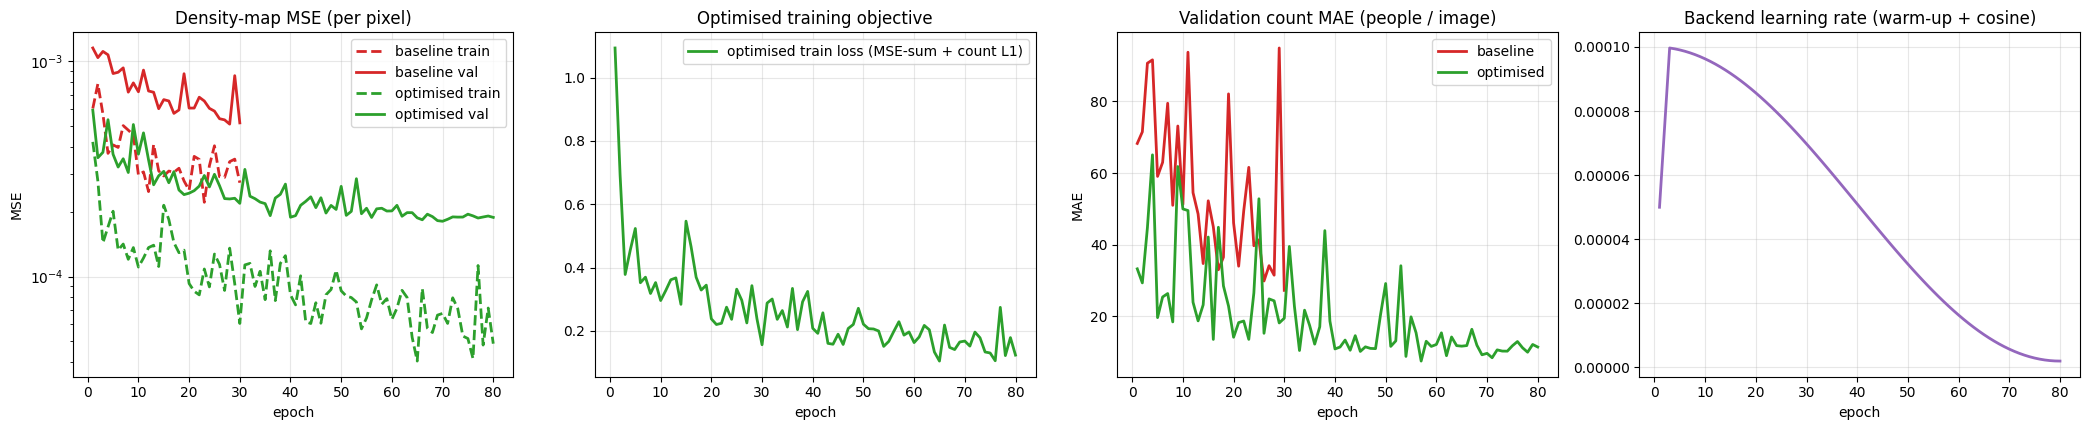

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(21, 4.4))
def curve(a, h, key, label, **kw):
    a.plot(h["epoch"], h[key], label=label, lw=2, **kw)
if hist_base is not None:
    curve(ax[0], hist_base, "train_mse", "baseline train", ls="--", color="tab:red")
    curve(ax[0], hist_base, "val_mse",   "baseline val",   color="tab:red")
    curve(ax[2], hist_base, "val_mae",   "baseline", color="tab:red")
curve(ax[0], hist_opt, "train_mse", "optimised train", ls="--", color="tab:green")
curve(ax[0], hist_opt, "val_mse",   "optimised val",   color="tab:green")
ax[0].set(title="Density-map MSE (per pixel)", xlabel="epoch", ylabel="MSE"); ax[0].set_yscale("log")
curve(ax[1], hist_opt, "train_loss", "optimised train loss (MSE-sum + count L1)", color="tab:green")
ax[1].set(title="Optimised training objective", xlabel="epoch")
curve(ax[2], hist_opt, "val_mae", "optimised", color="tab:green")
ax[2].set(title="Validation count MAE (people / image)", xlabel="epoch", ylabel="MAE")
ax[3].plot(hist_opt["epoch"], hist_opt["lr"], color="tab:purple", lw=2)
ax[3].set(title="Backend learning rate (warm-up + cosine)", xlabel="epoch")
for a in ax: a.grid(alpha=.3); a.legend() if a.get_legend_handles_labels()[0] else None
plt.tight_layout(); plt.savefig(FIG_DIR / "csrnet_loss_curves.png", dpi=150); plt.show()

## 5. CSRNet test results (held-out test set, never used for training or model selection)

                             MAE    RMSE    MAPE     R2
CSRNet (optimised)        10.308  16.887   8.324  0.968
CSRNet (original recipe)  32.110  52.313  28.207  0.698

Reference: published CSRNet on ShanghaiTech B  MAE 10.6 / RMSE 16.0 (after ~1000 epochs)


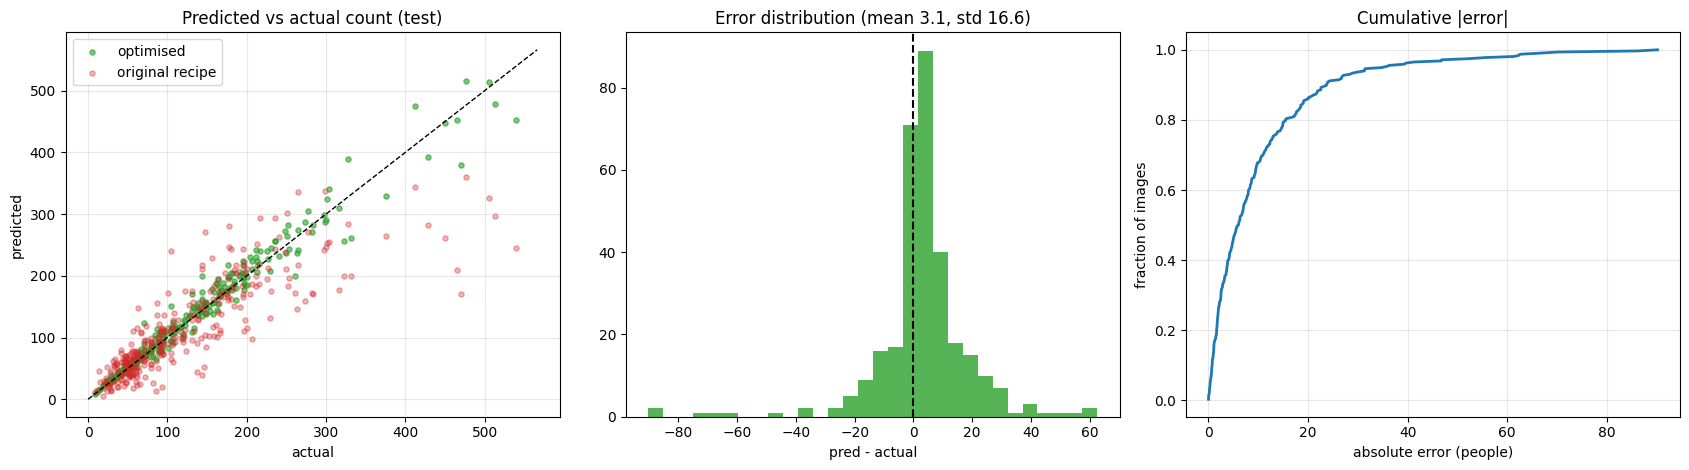

In [8]:
def metrics(p, g):
    return dict(MAE=float(np.mean(np.abs(p - g))), RMSE=float(np.sqrt(np.mean((p - g) ** 2))),
                MAPE=float(np.mean(np.abs(p - g) / np.maximum(g, 1)) * 100),
                R2=float(1 - np.sum((g - p) ** 2) / np.sum((g - g.mean()) ** 2)))

_, _, test_loader = make_loaders(False)
_, test_pred, test_gt = evaluate(model, test_loader)
m_opt = metrics(test_pred, test_gt); res = {"CSRNet (optimised)": m_opt}
if hist_base is not None:
    _, bp, _ = evaluate(base_model, test_loader); res["CSRNet (original recipe)"] = metrics(bp, test_gt)
print(pd.DataFrame(res).T.round(3).to_string())
print("\nReference: published CSRNet on ShanghaiTech B  MAE 10.6 / RMSE 16.0 (after ~1000 epochs)")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
ax[0].scatter(test_gt, test_pred, s=14, alpha=.6, color="tab:green", label="optimised")
if hist_base is not None: ax[0].scatter(test_gt, bp, s=14, alpha=.35, color="tab:red", label="original recipe")
lim = [0, max(test_gt.max(), test_pred.max()) * 1.05]; ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set(title="Predicted vs actual count (test)", xlabel="actual", ylabel="predicted"); ax[0].legend(); ax[0].grid(alpha=.3)
err = test_pred - test_gt
ax[1].hist(err, bins=30, color="tab:green", alpha=.8); ax[1].axvline(0, color="k", ls="--")
ax[1].set(title=f"Error distribution (mean {err.mean():.1f}, std {err.std():.1f})", xlabel="pred - actual")
ax[2].plot(np.sort(np.abs(err)), np.arange(1, len(err) + 1) / len(err), color="tab:blue", lw=2)
ax[2].set(title="Cumulative |error|", xlabel="absolute error (people)", ylabel="fraction of images"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "csrnet_test_results.png", dpi=150); plt.show()

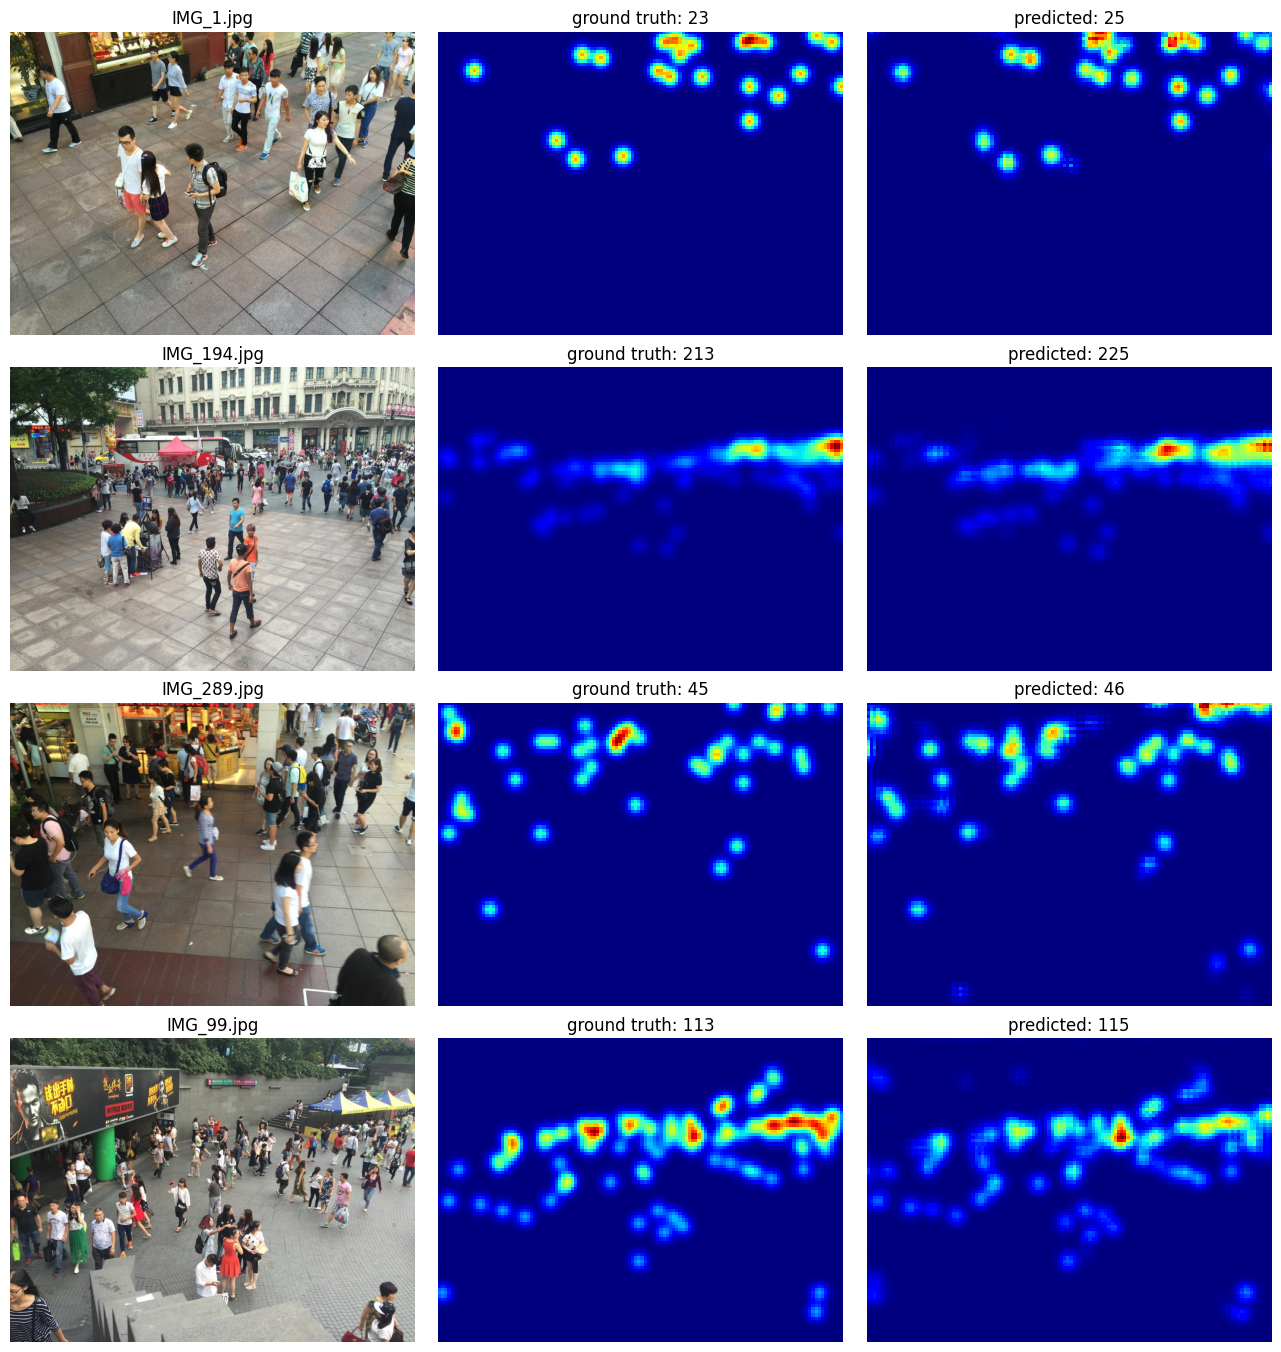

In [9]:
# Qualitative: image | ground-truth density | predicted density
idx = np.linspace(0, len(test_recs) - 1, 4).astype(int)
fig, ax = plt.subplots(len(idx), 3, figsize=(13, 3.4 * len(idx)))
model.eval()
for row, i in enumerate(idx):
    r = test_recs[i]; img = cv2.cvtColor(cv2.imread(r["path"]), cv2.COLOR_BGR2RGB)
    h8, w8 = r["density"].shape
    with torch.no_grad():
        out = model(to_tensor(img[:h8*8, :w8*8])[None].to(DEVICE)).float().cpu().numpy()[0, 0]
    ax[row, 0].imshow(img); ax[row, 0].set_title(r["name"])
    ax[row, 1].imshow(r["density"], cmap="jet"); ax[row, 1].set_title(f"ground truth: {r['count']:.0f}")
    ax[row, 2].imshow(np.maximum(out, 0), cmap="jet"); ax[row, 2].set_title(f"predicted: {out.sum():.0f}")
    for a in ax[row]: a.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "csrnet_density_samples.png", dpi=130); plt.show()

In [10]:
# Export CSRNet: plain state_dict (no 'module.' prefix) -> loads with strict=True in the backend
torch.save({k: v.cpu() for k, v in model.state_dict().items()}, OUT_DIR / "csrnet_model.pth")

# Same schema as the old crowd_counts.csv, but from the ordered, held-out test set
pd.DataFrame({"timestamp": pd.date_range("2025-01-01 08:00:00", periods=len(test_gt), freq="1min"),
              "image_id": np.arange(len(test_gt)), "predicted_count": test_pred, "actual_count": test_gt}
             ).to_csv(OUT_DIR / "crowd_counts.csv", index=False)
json.dump({k: v for k, v in res.items()}, open(OUT_DIR / "csrnet_results.json", "w"), indent=2)
print("saved csrnet_model.pth, crowd_counts.csv, csrnet_results.json")

saved csrnet_model.pth, crowd_counts.csv, csrnet_results.json


## 6. Use case — CSRNet **vs** CSRNet + LSTM

* **CSRNet only (reactive):** the dashboard shows the count in the current frame. To "predict" the next hour it can only assume *nothing changes* (persistence).
* **CSRNet + LSTM (predictive):** the LSTM reads the last 24 CSRNet counts and forecasts the next one, so a surge can be flagged **before** it happens.

Setup: a simulated 90-day hourly stream (daily peaks, weekends, festivals, random spikes). At every step the test image with the closest true count is shown to CSRNet → `observed` = CSRNet's real (noisy) count, `truth` = its annotated count. The forecast target is the **true** count of the next step. Chronological 70 / 15 / 15 split.

In [11]:
DAYS, SEQ = (25 if SMOKE else 90), 24
WARN, CRIT = 100, 200                                    # risk thresholds (people)

def hour_factor(h):
    if 6 <= h <= 9:   return 1.5 - abs(h - 7.5) * 0.3
    if 17 <= h <= 20: return 1.4 - abs(h - 18.5) * 0.25
    if 4 <= h < 6:    return 0.6
    if h >= 21 or h < 4: return 0.2
    return 0.8

def simulate_target(days, seed=SEED):
    rg = np.random.default_rng(seed)
    ts = pd.date_range("2024-01-01", periods=days * 24, freq="h")
    day_mult = np.where(ts.dayofweek >= 5, 1.4, np.where(ts.dayofweek == 4, 1.2, 1.0))
    fest = {d: rg.uniform(1.8, 3.0) for d in rg.choice(days, max(2, days // 25), replace=False)}
    f = np.array([hour_factor(t.hour) for t in ts]) * day_mult
    f = f * np.array([fest.get((t - ts[0]).days, 1.0) for t in ts])
    f = f * (1 + rg.uniform(-.15, .15, len(ts))) * np.where(rg.random(len(ts)) < .02, rg.uniform(1.3, 2.0, len(ts)), 1.0)
    c = f / np.percentile(f, 99) * 0.75 * test_gt.max()
    return ts, np.clip(c, test_gt.min(), test_gt.max())

ts, target = simulate_target(DAYS)
order = np.argsort(test_gt); sgt = test_gt[order]; rg = np.random.default_rng(SEED)
def pick(c):
    j = np.searchsorted(sgt, c); return rg.choice(order[max(0, j - 2): min(len(order), j + 3)])
sel = np.array([pick(c) for c in target])
observed, truth = test_pred[sel], test_gt[sel]           # what CSRNet reports vs what is really there
print(f"{len(ts)} hourly steps | truth {truth.min():.0f}-{truth.max():.0f} | CSRNet-vs-truth MAE on this stream: {np.abs(observed-truth).mean():.1f}")

n = len(ts) - SEQ
X = np.stack([observed[i:i + SEQ] for i in range(n)]); y = truth[SEQ:]            # y[i] = truth at step i+SEQ
cur_truth = truth[SEQ - 1: -1]                                                    # truth at the last observed step
i_tr, i_va = int(.70 * n), int(.85 * n)
lo, hi = float(min(X[:i_tr].min(), y[:i_tr].min())), float(max(X[:i_tr].max(), y[:i_tr].max()))
norm = lambda a: (a - lo) / (hi - lo); denorm = lambda a: a * (hi - lo) + lo
mk = lambda a, b: TensorDataset(torch.tensor(norm(X[a:b]), dtype=torch.float32).unsqueeze(-1),
                                torch.tensor(norm(y[a:b]), dtype=torch.float32).unsqueeze(-1))
dl_tr = DataLoader(mk(0, i_tr), batch_size=64, shuffle=True)
dl_va = DataLoader(mk(i_tr, i_va), batch_size=256); dl_te = DataLoader(mk(i_va, n), batch_size=256)
print("windows  train/val/test:", i_tr, i_va - i_tr, n - i_va)

2160 hourly steps | truth 23-539 | CSRNet-vs-truth MAE on this stream: 9.9
windows  train/val/test: 1495 320 321


In [12]:
class CrowdLSTM(nn.Module):                     # identical to backend/utils/model_defs.py (lstm + fc)
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        o, _ = self.lstm(x); return self.fc(o[:, -1, :])

LSTM_CFG = dict(input_size=1, hidden_size=64, num_layers=2, dropout=0.1, sequence_length=SEQ)
torch.manual_seed(SEED)
lstm = CrowdLSTM(**{k: v for k, v in LSTM_CFG.items() if k != "sequence_length"}).to(DEVICE)
opt = torch.optim.Adam(lstm.parameters(), lr=2e-3, weight_decay=1e-5)
sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=8)
LSTM_EPOCHS, PATIENCE = (3 if SMOKE else 200), 25
lh, best, best_state, bad = [], float("inf"), None, 0
for ep in range(LSTM_EPOCHS):
    lstm.train(); tl = 0
    for xb, yb in dl_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = F.mse_loss(lstm(xb), yb); opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(lstm.parameters(), 1.0); opt.step(); tl += loss.item() * len(xb)
    lstm.eval()
    with torch.no_grad(): vl = sum(F.mse_loss(lstm(a.to(DEVICE)), b.to(DEVICE)).item() * len(a) for a, b in dl_va) / (i_va - i_tr)
    lh.append(dict(epoch=ep + 1, train_loss=tl / i_tr, val_loss=vl)); sch.step(vl)
    if vl < best - 1e-6: best, bad = vl, 0; best_state = copy.deepcopy(lstm.state_dict())      # deepcopy: old code kept a shallow copy
    else:
        bad += 1
        if bad >= PATIENCE: print("early stop at epoch", ep + 1); break
    if (ep + 1) % 20 == 0: print(f"ep {ep+1:3d} train {tl/i_tr:.5f} val {vl:.5f}")
lstm.load_state_dict(best_state); lh = pd.DataFrame(lh); lh.to_csv(OUT_DIR / "lstm_history.csv", index=False)
print("best val loss (normalised MSE):", round(best, 5))

ep  20 train 0.00311 val 0.00626
ep  40 train 0.00234 val 0.00751
early stop at epoch 46
best val loss (normalised MSE): 0.00578


In [13]:
# Predictions on the chronological TEST windows
lstm.eval()
with torch.no_grad():
    p_lstm = np.concatenate([lstm(a.to(DEVICE)).cpu().numpy() for a, _ in dl_te]).ravel()
p_lstm = np.maximum(denorm(p_lstm), 0)
sl = slice(i_va, n); Xt, yt, cur = X[sl], y[sl], cur_truth[sl]
preds = {"CSRNet only (reactive)":        Xt[:, -1],                 # persistence: next = current CSRNet count
         "CSRNet + moving avg (3h)":      Xt[:, -3:].mean(1),
         "CSRNet + seasonal (24h ago)":   Xt[:, 0],                  # same hour yesterday
         "CSRNet + LSTM (predictive)":    p_lstm}
table = pd.DataFrame({k: metrics(v, yt) for k, v in preds.items()}).T
print("Next-hour forecast vs TRUE next-hour count (chronological test windows)\n"); print(table.round(3).to_string())

level = lambda a: np.digitize(a, [WARN, CRIT])                       # 0 safe, 1 warning, 2 critical
rows = {}
for k, v in preds.items():
    tp = ((v >= CRIT) & (yt >= CRIT)).sum(); fp = ((v >= CRIT) & (yt < CRIT)).sum(); fn = ((v < CRIT) & (yt >= CRIT)).sum()
    onset = (cur < CRIT) & (yt >= CRIT)                               # crowd is still below CRIT now but crosses it next hour
    rows[k] = dict(risk_acc=(level(v) == level(yt)).mean(), crit_precision=tp / max(tp + fp, 1), crit_recall=tp / max(tp + fn, 1),
                   surge_onsets=int(onset.sum()), onsets_caught=int(((v >= CRIT) & onset).sum()), false_alarms=int(fp))
risk = pd.DataFrame(rows).T; print("\nRisk / early-warning (critical >= %d people)\n" % CRIT); print(risk.round(3).to_string())
table.join(risk).to_csv(OUT_DIR / "usecase_comparison.csv")

Next-hour forecast vs TRUE next-hour count (chronological test windows)

                                MAE    RMSE    MAPE     R2
CSRNet only (reactive)       32.099  49.739  37.430  0.499
CSRNet + moving avg (3h)     46.820  64.480  65.905  0.158
CSRNet + seasonal (24h ago)  21.921  36.462  19.417  0.731
CSRNet + LSTM (predictive)   17.514  27.282  19.222  0.849

Risk / early-warning (critical >= 200 people)

                             risk_acc  crit_precision  crit_recall  surge_onsets  onsets_caught  false_alarms
CSRNet only (reactive)          0.757           0.444        0.541          19.0            3.0          25.0
CSRNet + moving avg (3h)        0.660           0.182        0.162          19.0            0.0          27.0
CSRNet + seasonal (24h ago)     0.847           0.578        0.703          19.0           10.0          19.0
CSRNet + LSTM (predictive)      0.850           0.676        0.676          19.0            7.0          12.0


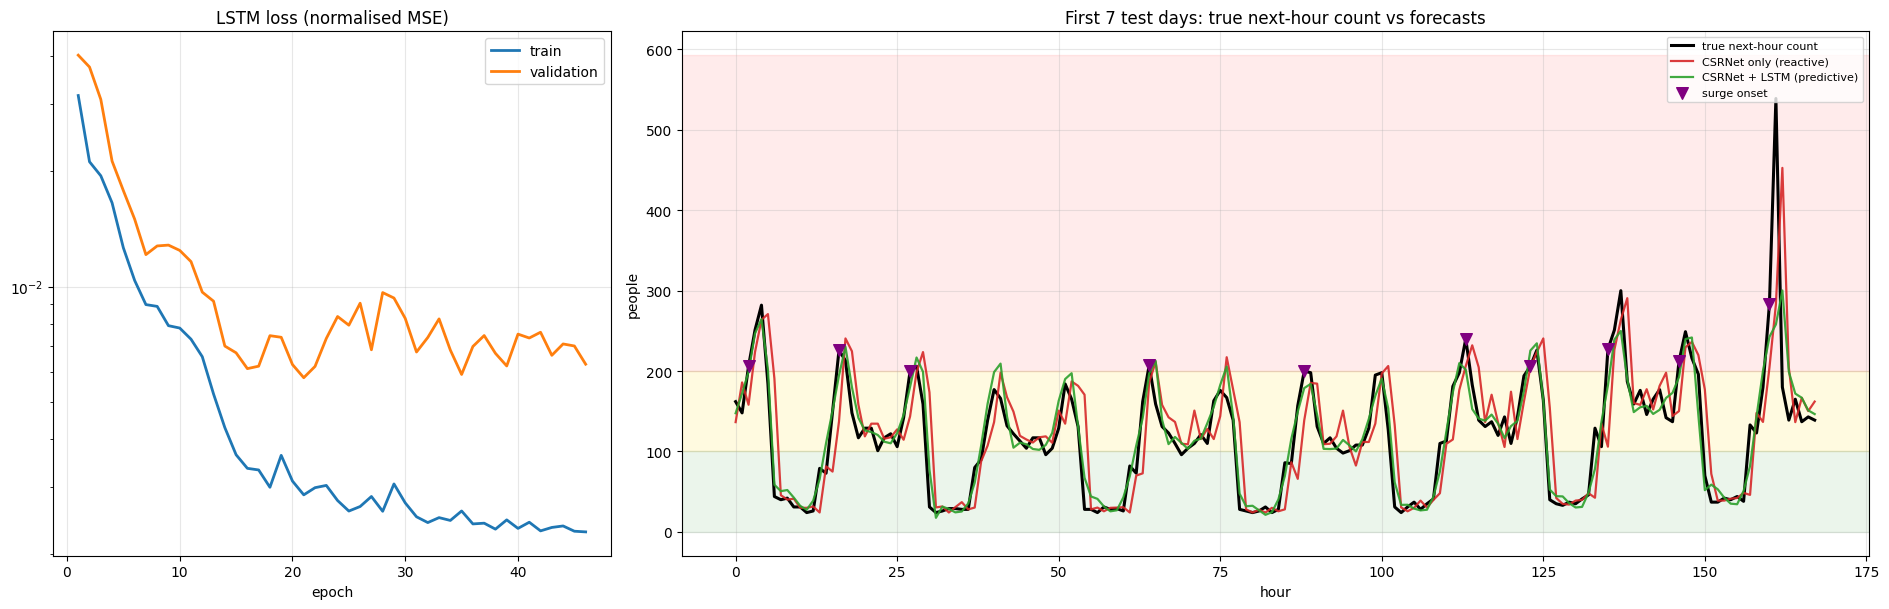

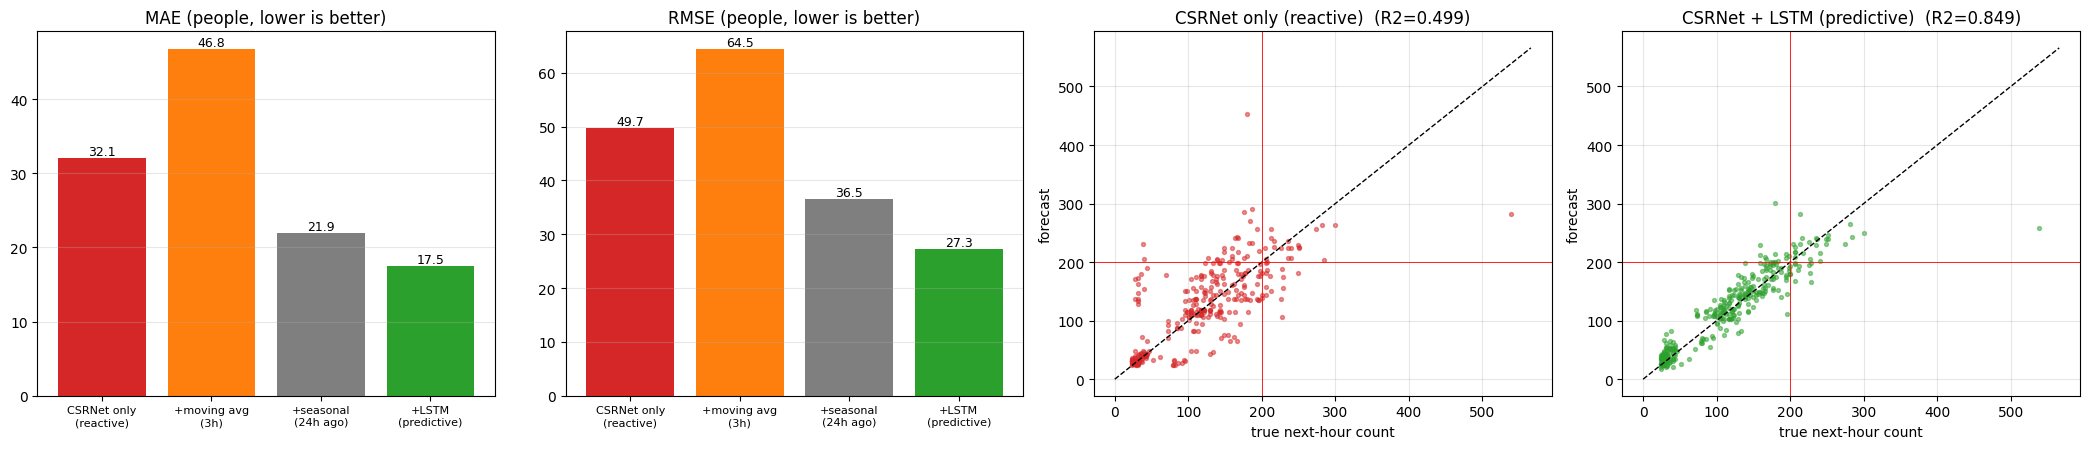

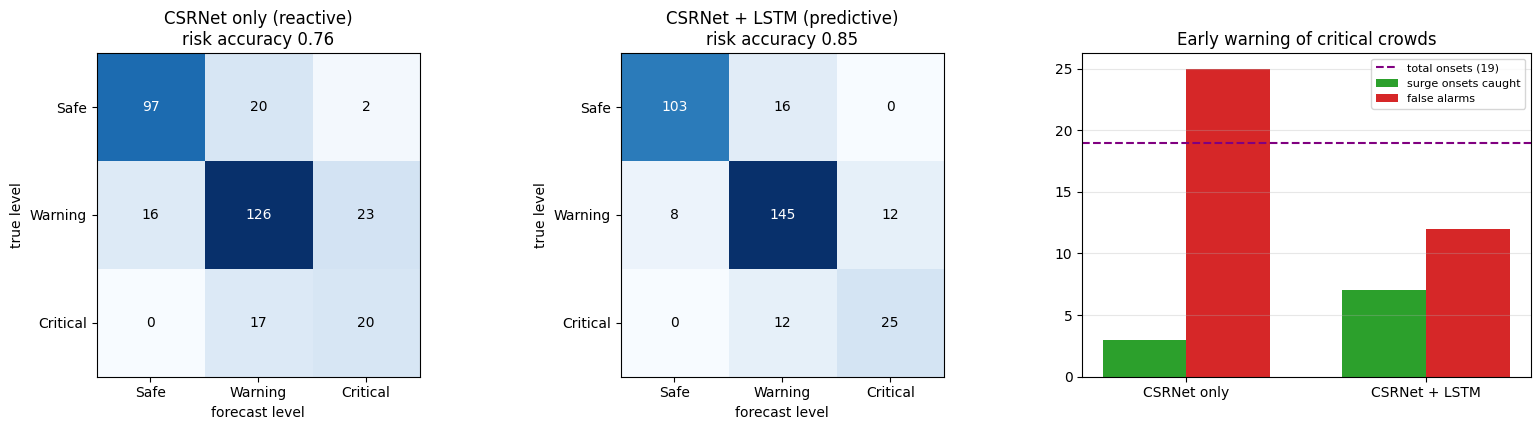

In [14]:
colors = {"CSRNet only (reactive)": "tab:red", "CSRNet + moving avg (3h)": "tab:orange",
          "CSRNet + seasonal (24h ago)": "tab:gray", "CSRNet + LSTM (predictive)": "tab:green"}
T = 168 if len(yt) >= 168 else len(yt)

# --- Figure A: LSTM loss + timeline
fig = plt.figure(figsize=(19, 6.2)); g = fig.add_gridspec(1, 3)
a0 = fig.add_subplot(g[0, 0]); a0.plot(lh["epoch"], lh["train_loss"], label="train", lw=2); a0.plot(lh["epoch"], lh["val_loss"], label="validation", lw=2)
a0.set(title="LSTM loss (normalised MSE)", xlabel="epoch", yscale="log"); a0.legend(); a0.grid(alpha=.3)
a1 = fig.add_subplot(g[0, 1:]); x = np.arange(T)
a1.axhspan(0, WARN, color="green", alpha=.08); a1.axhspan(WARN, CRIT, color="gold", alpha=.12); a1.axhspan(CRIT, max(yt.max(), 1) * 1.1, color="red", alpha=.08)
a1.plot(x, yt[:T], "k", lw=2.2, label="true next-hour count")
for k in ["CSRNet only (reactive)", "CSRNet + LSTM (predictive)"]: a1.plot(x, preds[k][:T], color=colors[k], lw=1.6, label=k, alpha=.9)
on = np.where(((cur < CRIT) & (yt >= CRIT))[:T])[0]; a1.scatter(on, yt[on], marker="v", s=70, color="purple", zorder=5, label="surge onset")
a1.set(title="First 7 test days: true next-hour count vs forecasts", xlabel="hour", ylabel="people"); a1.legend(loc="upper right", fontsize=8); a1.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "lstm_loss_and_timeline.png", dpi=150); plt.show()

# --- Figure B: metric bars + scatters
fig, ax = plt.subplots(1, 4, figsize=(21, 4.6)); names = list(preds)
for a, m in zip(ax[:2], ["MAE", "RMSE"]):
    a.bar(range(4), table[m], color=[colors[k] for k in names]); a.set_xticks(range(4)); a.set_xticklabels([n.replace("CSRNet + ", "+").replace(" (", "\n(") for n in names], fontsize=8)
    a.set_title(f"{m} (people, lower is better)"); a.grid(alpha=.3, axis="y")
    for i, v in enumerate(table[m]): a.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
for a, k in zip(ax[2:], ["CSRNet only (reactive)", "CSRNet + LSTM (predictive)"]):
    a.scatter(yt, preds[k], s=8, alpha=.5, color=colors[k]); lim = [0, max(yt.max(), preds[k].max()) * 1.05]; a.plot(lim, lim, "k--", lw=1)
    a.axvline(CRIT, color="r", lw=.6); a.axhline(CRIT, color="r", lw=.6)
    a.set(title=f"{k}  (R2={table.loc[k, 'R2']:.3f})", xlabel="true next-hour count", ylabel="forecast"); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG_DIR / "usecase_metrics.png", dpi=150); plt.show()

# --- Figure C: risk confusion matrices + early-warning counts
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4)); lab = ["Safe", "Warning", "Critical"]
for a, k in zip(ax[:2], ["CSRNet only (reactive)", "CSRNet + LSTM (predictive)"]):
    cm = np.zeros((3, 3), int)
    for t, p in zip(level(yt), level(preds[k])): cm[t, p] += 1
    a.imshow(cm, cmap="Blues"); a.set(xticks=range(3), yticks=range(3), xticklabels=lab, yticklabels=lab, xlabel="forecast level", ylabel="true level", title=f"{k}\nrisk accuracy {rows[k]['risk_acc']:.2f}")
    for i in range(3):
        for j in range(3): a.text(j, i, cm[i, j], ha="center", va="center", color="w" if cm[i, j] > cm.max() / 2 else "k")
w = 0.35; xs = np.arange(2); ks = ["CSRNet only (reactive)", "CSRNet + LSTM (predictive)"]
ax[2].bar(xs - w/2, [rows[k]["onsets_caught"] for k in ks], w, label="surge onsets caught", color="tab:green")
ax[2].bar(xs + w/2, [rows[k]["false_alarms"] for k in ks], w, label="false alarms", color="tab:red")
ax[2].axhline(rows[ks[0]]["surge_onsets"], color="purple", ls="--", label=f"total onsets ({rows[ks[0]]['surge_onsets']})")
ax[2].set_xticks(xs); ax[2].set_xticklabels(["CSRNet only", "CSRNet + LSTM"]); ax[2].set_title("Early warning of critical crowds"); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.savefig(FIG_DIR / "usecase_risk.png", dpi=150); plt.show()

In [15]:
# Export LSTM in the format backend/utils/model_registry.py reads (state_dict + config + scaler)
scaler = {"method": "minmax", "min": lo, "max": hi}
torch.save({"state_dict": {k: v.cpu() for k, v in lstm.state_dict().items()}, "config": LSTM_CFG, "scaler": scaler}, OUT_DIR / "lstm_model.pth")
json.dump(scaler, open(OUT_DIR / "lstm_scaler.json", "w"))
print("saved lstm_model.pth + lstm_scaler.json  ->  scaler", scaler)

saved lstm_model.pth + lstm_scaler.json  ->  scaler {'method': 'minmax', 'min': 24.0, 'max': 539.0}


## 7. Backend compatibility check (mirrors `backend/utils/preprocessing.py`)

In [16]:
from PIL import Image
from torchvision import transforms
bt = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

sd = torch.load(OUT_DIR / "csrnet_model.pth", map_location="cpu")
chk = CSRNet(pretrained=False); chk.load_state_dict(sd, strict=True)            # strict load, like the backend
assert not any(k.startswith("module.") for k in sd), "state_dict has DataParallel prefix"
chk.to(DEVICE).eval(); diffs = []
for k, r in enumerate(test_recs[:5]):
    x = bt(Image.open(r["path"]).convert("RGB")).unsqueeze(0).to(DEVICE)         # exactly what /predict-count does
    with torch.no_grad(): api_count = max(chk(x).sum().item(), 0)
    diffs.append(abs(api_count - test_pred[k]))
print("csrnet keys ok; max |backend-style count - notebook count| over 5 images:", round(max(diffs), 2))

pl = torch.load(OUT_DIR / "lstm_model.pth", map_location="cpu")
chk2 = CrowdLSTM(**{k: v for k, v in pl["config"].items() if k != "sequence_length"}); chk2.load_state_dict(pl["state_dict"], strict=True); chk2.eval()
w = Xt[0]; z = torch.tensor(norm(w), dtype=torch.float32).view(1, SEQ, 1)
with torch.no_grad(): f = float(denorm(chk2(z).item()))
print(f"lstm keys ok; sample /predict-future style forecast = {f:.1f} (notebook = {p_lstm[0]:.1f})")
print("\nCopy these into backend/models/:", [p.name for p in sorted(OUT_DIR.glob('*.pth'))] + ["lstm_scaler.json"])

csrnet keys ok; max |backend-style count - notebook count| over 5 images: 0.01
lstm keys ok; sample /predict-future style forecast = 147.6 (notebook = 147.6)

Copy these into backend/models/: ['csrnet_model.pth', 'lstm_model.pth', 'lstm_scaler.json']


## 8. Further optimisations (not run here)

* **Train on Part A + B** (dense crowds) and use geometry-adaptive Gaussian kernels for Part A — temples resemble Part A more than Part B.
* **More epochs** (`epochs = 200+`) — CSRNet's published numbers need hundreds of epochs; the cosine schedule scales automatically.
* **Bayesian / DM-Count losses** or **multi-scale** heads (MCNN / SANet) for dense scenes; **test-time flip averaging**.
* **Replace the simulated stream** with real per-camera counts, add features to the LSTM (hour, day-of-week, festival flag) and predict several steps ahead (quantile loss → confidence band for the dashboard).
* **Backend**: expose `predicted_next_count` risk through `/risk` (already implemented) and stream `/dashboard-data` from live counts.

In [ ]:
# ============ FINAL RESULT CSVs (run after the whole notebook) ============
# accuracy_pct = 100 - percentage error of that prediction (100 = exact); dataset-level accuracy = 100 - MAPE
def rlevel(v): return ["Safe", "Warning", "Critical"][int(np.digitize(v, [WARN, CRIT]))]

# 1) every CSRNet test image: actual vs predicted
pe = np.abs(test_pred - test_gt) / np.maximum(test_gt, 1) * 100
img = pd.DataFrame({"image": [r["name"] for r in test_recs], "actual_count": test_gt, "predicted_count": np.round(test_pred, 2),
                    "abs_error": np.round(np.abs(test_pred - test_gt), 2), "pct_error": np.round(pe, 2),
                    "accuracy_pct": np.round(np.maximum(0, 100 - pe), 2), "within_10pct": (pe <= 10).astype(int), "within_20pct": (pe <= 20).astype(int),
                    "actual_risk": [rlevel(v) for v in test_gt], "predicted_risk": [rlevel(v) for v in test_pred]})
img.to_csv("/kaggle/working/final_test_predictions.csv", index=False)

# 2) every forecast test hour: true next-hour count vs each method
t_target = ts[i_va + SEQ:]
fc = pd.DataFrame({"timestamp": t_target, "csrnet_count_now": Xt[:, -1], "true_count_now": cur, "true_next_hour": yt})
for k, v in preds.items(): fc["forecast | " + k] = np.round(v, 2)
fc["true_risk_next_hour"] = [rlevel(v) for v in yt]; fc["lstm_risk_forecast"] = [rlevel(v) for v in p_lstm]
fc["lstm_abs_error"] = np.round(np.abs(p_lstm - yt), 2)
fc["lstm_accuracy_pct"] = np.round(np.maximum(0, 100 - np.abs(p_lstm - yt) / np.maximum(yt, 1) * 100), 2)
fc.to_csv("/kaggle/working/final_forecast_predictions.csv", index=False)

# 3) accuracy summary
summ = []
m = metrics(test_pred, test_gt)
summ.append(dict(task=f"CSRNet count - test ({len(test_gt)} images)", model="CSRNet optimised", MAE=m["MAE"], RMSE=m["RMSE"], MAPE=m["MAPE"], accuracy_pct=100 - m["MAPE"], R2=m["R2"],
                 within_10pct=(pe <= 10).mean() * 100, within_20pct=(pe <= 20).mean() * 100, risk_level_accuracy=np.mean([rlevel(a) == rlevel(b) for a, b in zip(test_gt, test_pred)]) * 100))
for k, v in preds.items():
    m = metrics(v, yt); e = np.abs(v - yt) / np.maximum(yt, 1) * 100
    summ.append(dict(task=f"Next-hour forecast ({len(yt)} test hours)", model=k, MAE=m["MAE"], RMSE=m["RMSE"], MAPE=m["MAPE"], accuracy_pct=100 - m["MAPE"], R2=m["R2"],
                     within_10pct=(e <= 10).mean() * 100, within_20pct=(e <= 20).mean() * 100, risk_level_accuracy=rows[k]["risk_acc"] * 100))
final_summary = pd.DataFrame(summ).round(3); final_summary.to_csv("/kaggle/working/final_accuracy_summary.csv", index=False)
print(final_summary.to_string(index=False))
print("\nsaved to /kaggle/working: final_test_predictions.csv, final_forecast_predictions.csv, final_accuracy_summary.csv")
